Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 39s 70ms/step - accuracy: 0.8689 - loss: 0.4546 - val_accuracy: 0.9779 - val_loss: 0.0699
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 66ms/step - accuracy: 0.9821 - loss: 0.0592 - val_accuracy: 0.9842 - val_loss: 0.0492
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 67ms/step - accuracy: 0.9872 - loss: 0.0406 - val_accuracy: 0.9900 - val_loss: 0.0320
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 67ms/step - accuracy: 0.9906 - loss: 0.0279 - val_accuracy: 0.9901 - val_loss: 0.0328
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 67ms/step - accuracy: 0.9930 - loss: 0.0218 - val_accuracy: 0.9913 - val_loss: 0.0289
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 68ms/step - accuracy: 0.9948 - loss: 0.0171 - val_accuracy: 0.9899 - val_loss: 0.0293
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 68ms/step - accuracy: 0.9961 - loss: 0.0125 - val_accuracy: 0.9891 - val_loss: 0.0337
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 69ms/step - accuracy: 0.9970 - loss: 0.0097 - 

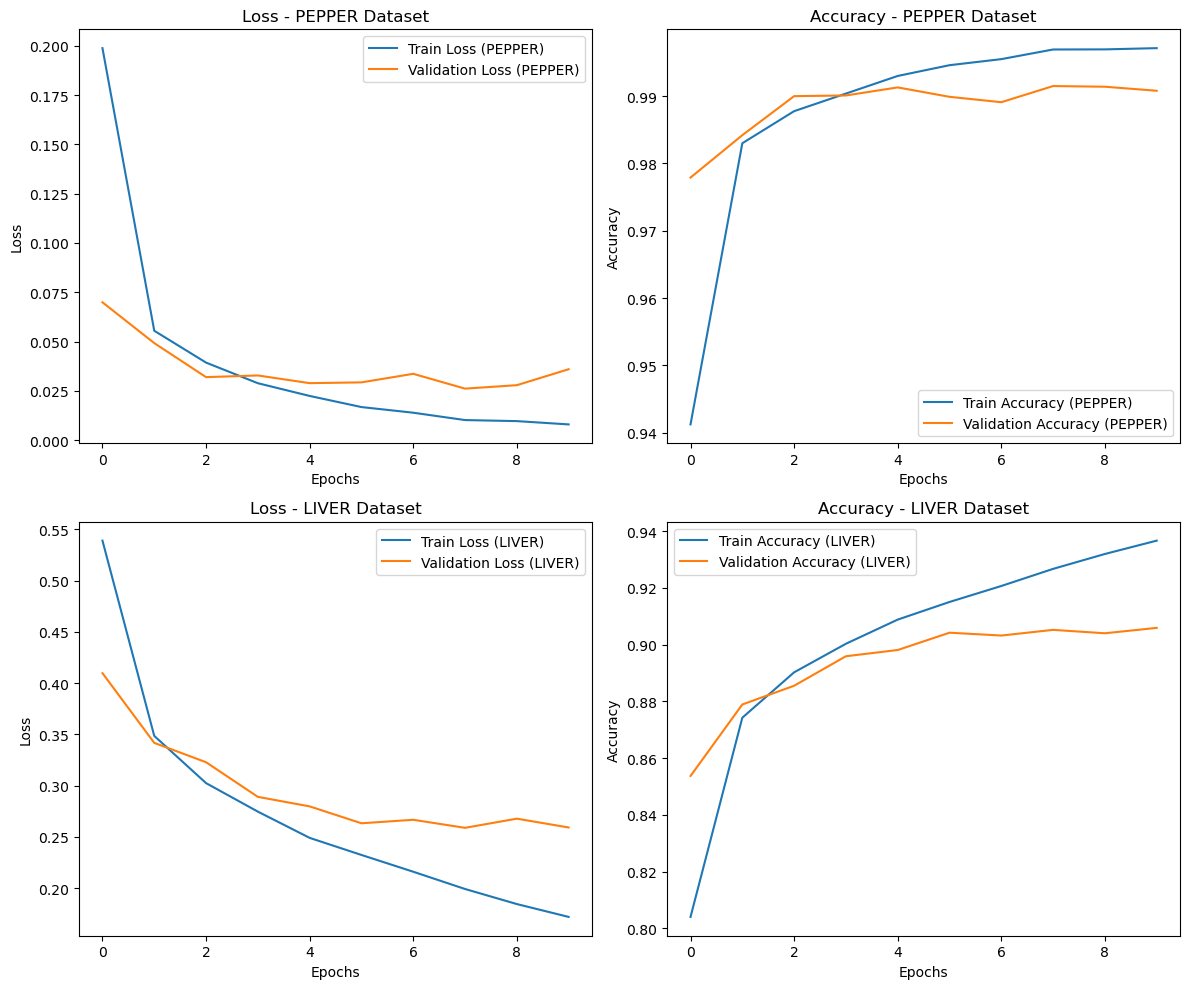

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step

Layer 1 feature map shape: (1, 26, 26, 32)


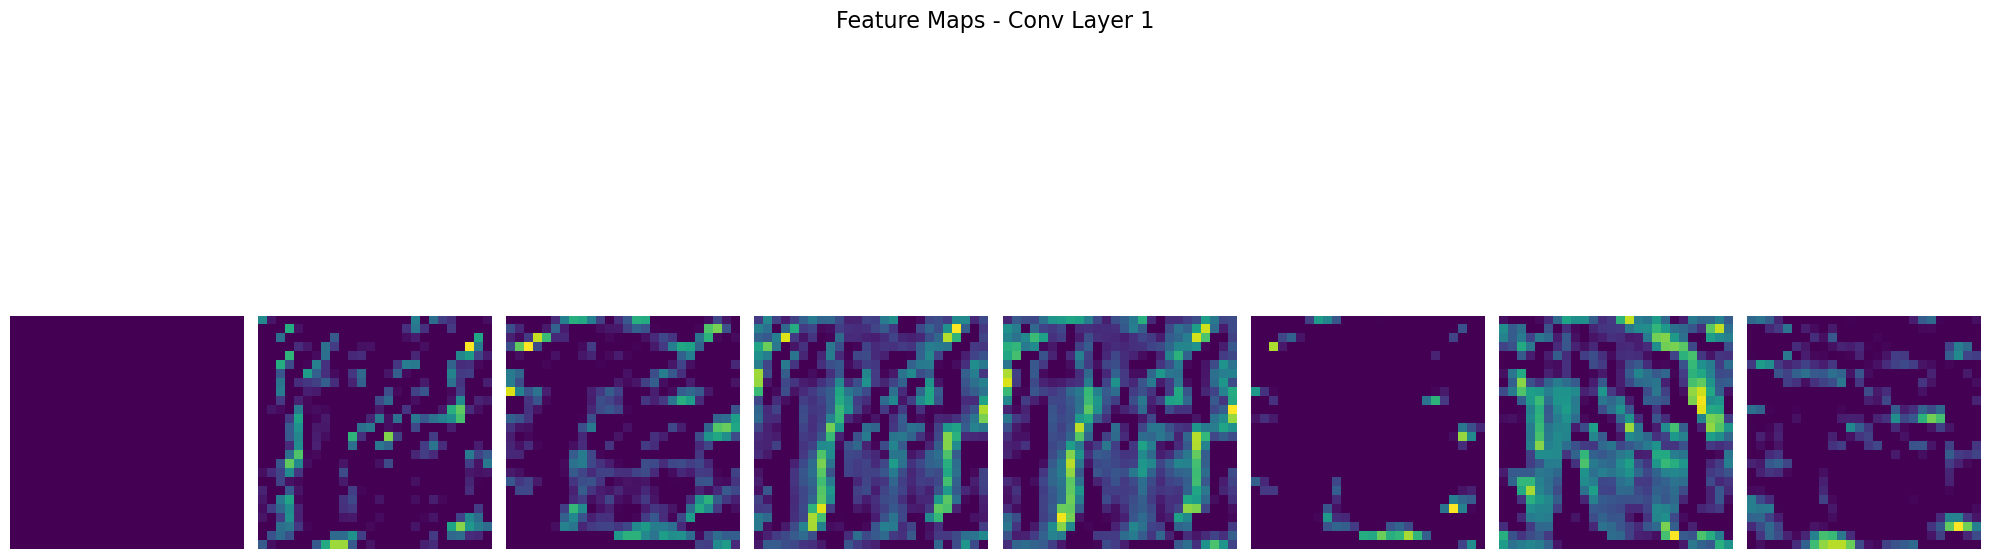


Layer 2 feature map shape: (1, 11, 11, 64)


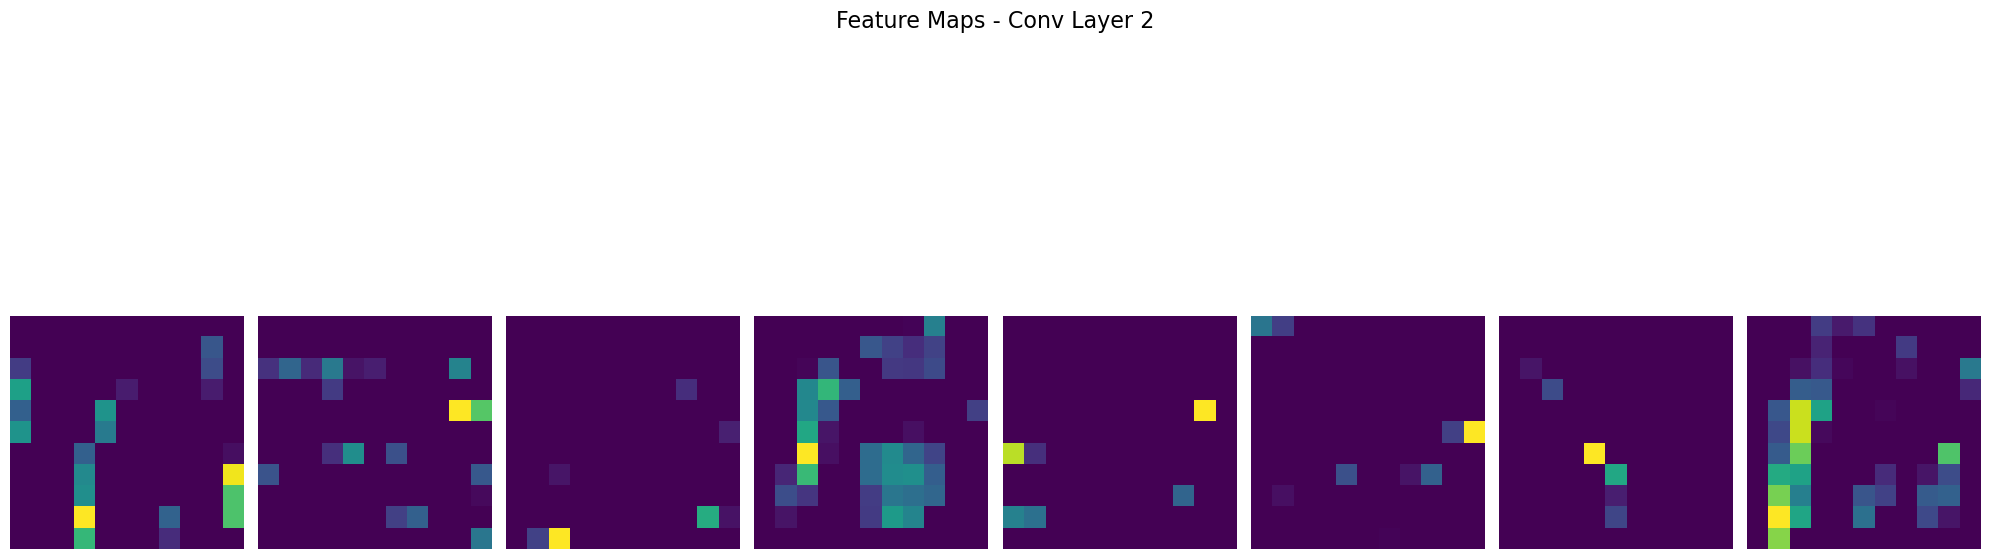

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import cv2  # For loading your custom images
from tensorflow.keras.datasets import mnist, fashion_mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, Flatten, Dense, Input, MaxPooling2D

# ============================
# 1. Load and Preprocess Datasets
# ============================
# Load datasets
(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = mnist.load_data()
(X_train_fashion, y_train_fashion), (X_test_fashion, y_test_fashion) = fashion_mnist.load_data()

# Preprocess data: normalize and add channel dimension
X_train_mnist = X_train_mnist.astype('float32') / 255.0
X_test_mnist = X_test_mnist.astype('float32') / 255.0
X_train_fashion = X_train_fashion.astype('float32') / 255.0
X_test_fashion = X_test_fashion.astype('float32') / 255.0

X_train_mnist = np.expand_dims(X_train_mnist, axis=-1)
X_test_mnist = np.expand_dims(X_test_mnist, axis=-1)
X_train_fashion = np.expand_dims(X_train_fashion, axis=-1)
X_test_fashion = np.expand_dims(X_test_fashion, axis=-1)

# ============================
# 2. Define a Simple CNN Model
# ============================
def create_cnn_model(input_shape):
    inputs = Input(shape=input_shape)
    x = Conv2D(32, (3, 3), activation='relu')(inputs)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Conv2D(64, (3, 3), activation='relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    outputs = Dense(10, activation='softmax')(x)
    model = Model(inputs, outputs)
    return model

# ============================
# 3. Compile and Train the Model
# ============================
def train_model(X_train, y_train, X_test, y_test):
    cnn_model = create_cnn_model(X_train.shape[1:])
    cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = cnn_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=128)
    return history, cnn_model

# Train models for both datasets
history_mnist, model_mnist = train_model(X_train_mnist, y_train_mnist, X_test_mnist, y_test_mnist)
history_fashion, model_fashion = train_model(X_train_fashion, y_train_fashion, X_test_fashion, y_test_fashion)

# ============================
# 4. Plot Loss, Accuracy, and Feature Maps
# ============================
def plot_qcnn_results(history_mnist, history_fashion, model, dataset_name, selected_image_path=None):
    # Print significant values for the metrics
    print("=== PEPPER Dataset Metrics (from MNIST-trained model) ===")
    print("Train Loss:", history_mnist.history['loss'])
    print("Validation Loss:", history_mnist.history['val_loss'])
    print("Train Accuracy:", history_mnist.history['accuracy'])
    print("Validation Accuracy:", history_mnist.history['val_accuracy'])
    
    print("\n=== LIVER Dataset Metrics (from FashionMNIST-trained model) ===")
    print("Train Loss:", history_fashion.history['loss'])
    print("Validation Loss:", history_fashion.history['val_loss'])
    print("Train Accuracy:", history_fashion.history['accuracy'])
    print("Validation Accuracy:", history_fashion.history['val_accuracy'])
    
    # Plot Loss and Accuracy for PEPPER and LIVER datasets
    fig, ax = plt.subplots(2, 2, figsize=(12, 10))
    
    # PEPPER Loss and Accuracy
    ax[0, 0].plot(history_mnist.history['loss'], label='Train Loss (PEPPER)')
    ax[0, 0].plot(history_mnist.history['val_loss'], label='Validation Loss (PEPPER)')
    ax[0, 0].set_title('Loss - PEPPER Dataset')
    ax[0, 0].set_xlabel('Epochs')
    ax[0, 0].set_ylabel('Loss')
    ax[0, 0].legend()

    ax[0, 1].plot(history_mnist.history['accuracy'], label='Train Accuracy (PEPPER)')
    ax[0, 1].plot(history_mnist.history['val_accuracy'], label='Validation Accuracy (PEPPER)')
    ax[0, 1].set_title('Accuracy - PEPPER Dataset')
    ax[0, 1].set_xlabel('Epochs')
    ax[0, 1].set_ylabel('Accuracy')
    ax[0, 1].legend()

    # LIVER Loss and Accuracy
    ax[1, 0].plot(history_fashion.history['loss'], label='Train Loss (LIVER)')
    ax[1, 0].plot(history_fashion.history['val_loss'], label='Validation Loss (LIVER)')
    ax[1, 0].set_title('Loss - LIVER Dataset')
    ax[1, 0].set_xlabel('Epochs')
    ax[1, 0].set_ylabel('Loss')
    ax[1, 0].legend()

    ax[1, 1].plot(history_fashion.history['accuracy'], label='Train Accuracy (LIVER)')
    ax[1, 1].plot(history_fashion.history['val_accuracy'], label='Validation Accuracy (LIVER)')
    ax[1, 1].set_title('Accuracy - LIVER Dataset')
    ax[1, 1].set_xlabel('Epochs')
    ax[1, 1].set_ylabel('Accuracy')
    ax[1, 1].legend()
    
    plt.tight_layout()
    plt.show()

    # ----------------------------
    # Feature Map Visualization
    # ----------------------------
    # Create a new model that outputs the feature maps from each convolutional layer
    layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name]
    feature_model = Model(inputs=model.input, outputs=layer_outputs)
    
    # Load the selected image if provided; otherwise, use a sample from MNIST test set
    if selected_image_path is not None:
        img = cv2.imread(selected_image_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError(f"Image not found at path: {selected_image_path}")
        img = cv2.resize(img, (28, 28))
        img = img.astype('float32') / 255.0
        image = np.expand_dims(img, axis=-1)  # Shape becomes (28, 28, 1)
        image = np.expand_dims(image, axis=0)   # Shape becomes (1, 28, 28, 1)
    else:
        # Default to first MNIST test sample if no image is provided
        image = X_test_mnist[0].reshape(1, 28, 28, 1)
    
    # Obtain feature maps
    feature_maps = feature_model.predict(image)
    
    # Loop through each convolutional layer's output and plot the first 8 feature maps
    for layer_index, feature_map in enumerate(feature_maps):
        num_features = feature_map.shape[-1]
        num_plots = min(8, num_features)
        fig, ax = plt.subplots(1, num_plots, figsize=(20, 8))
        print(f"\nLayer {layer_index+1} feature map shape: {feature_map.shape}")
        for i in range(num_plots):
            ax[i].imshow(feature_map[0, :, :, i], cmap='viridis')
            ax[i].axis('off')
        plt.suptitle(f'Feature Maps - Conv Layer {layer_index + 1}', fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
       

# ============================
# 5. Image Dictionary and Execution
# ============================
# Dictionary of custom image paths (update the paths if necessary)
images = {
    "Pepper": r"C:\Users\HP\Desktop\qcnn new1\pepperimage.tiff",
    "Liver": r"C:\Users\HP\Desktop\qcnn new1\3Dircadb1.11\3Dircadb1.11\Liver_11.jpg"
}

# Choose which image to use for feature map visualization:
selected_image = images["Pepper"]  # Change to "Liver" to use the liver image

# Call the plotting function (using the MNIST-trained model for feature extraction)
plot_qcnn_results(history_mnist, history_fashion, model_mnist, 'PEPPER', selected_image)


Original Image 1 shape: (721, 811, 3)
Original Image 2 shape: (512, 512, 3)
Resized Image 1 (grayscale) shape: (256, 256)
Resized Image 2 (grayscale) shape: (256, 256)
Canny Edges Image 1 shape: (256, 256) Edge pixels count: 6983
Canny Edges Image 2 shape: (256, 256) Edge pixels count: 7014
SLIC Segmentation Image 1 - unique segments: 60
SLIC Segmentation Image 2 - unique segments: 51
Labeled Image 1 - number of regions: 60
Labeled Image 2 - number of regions: 51
LBP Image 1 - shape: (256, 256) Unique values: [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
LBP Image 2 - shape: (256, 256) Unique values: [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]


C:\Users\HP\anaconda3\Lib\site-packages\skimage\feature\texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 541s 9us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
VGG16 features Image 1 - length: 25088
VGG16 features Image 2 - length: 25088
Quantum Edges Image 1 - shape: (256, 256) min: 0.5911261523704271 max: 185.00731928542078
Quantum Edges Image 2 - shape: (256, 256) min: 0.11237548738515192 max: 206.62479621146957


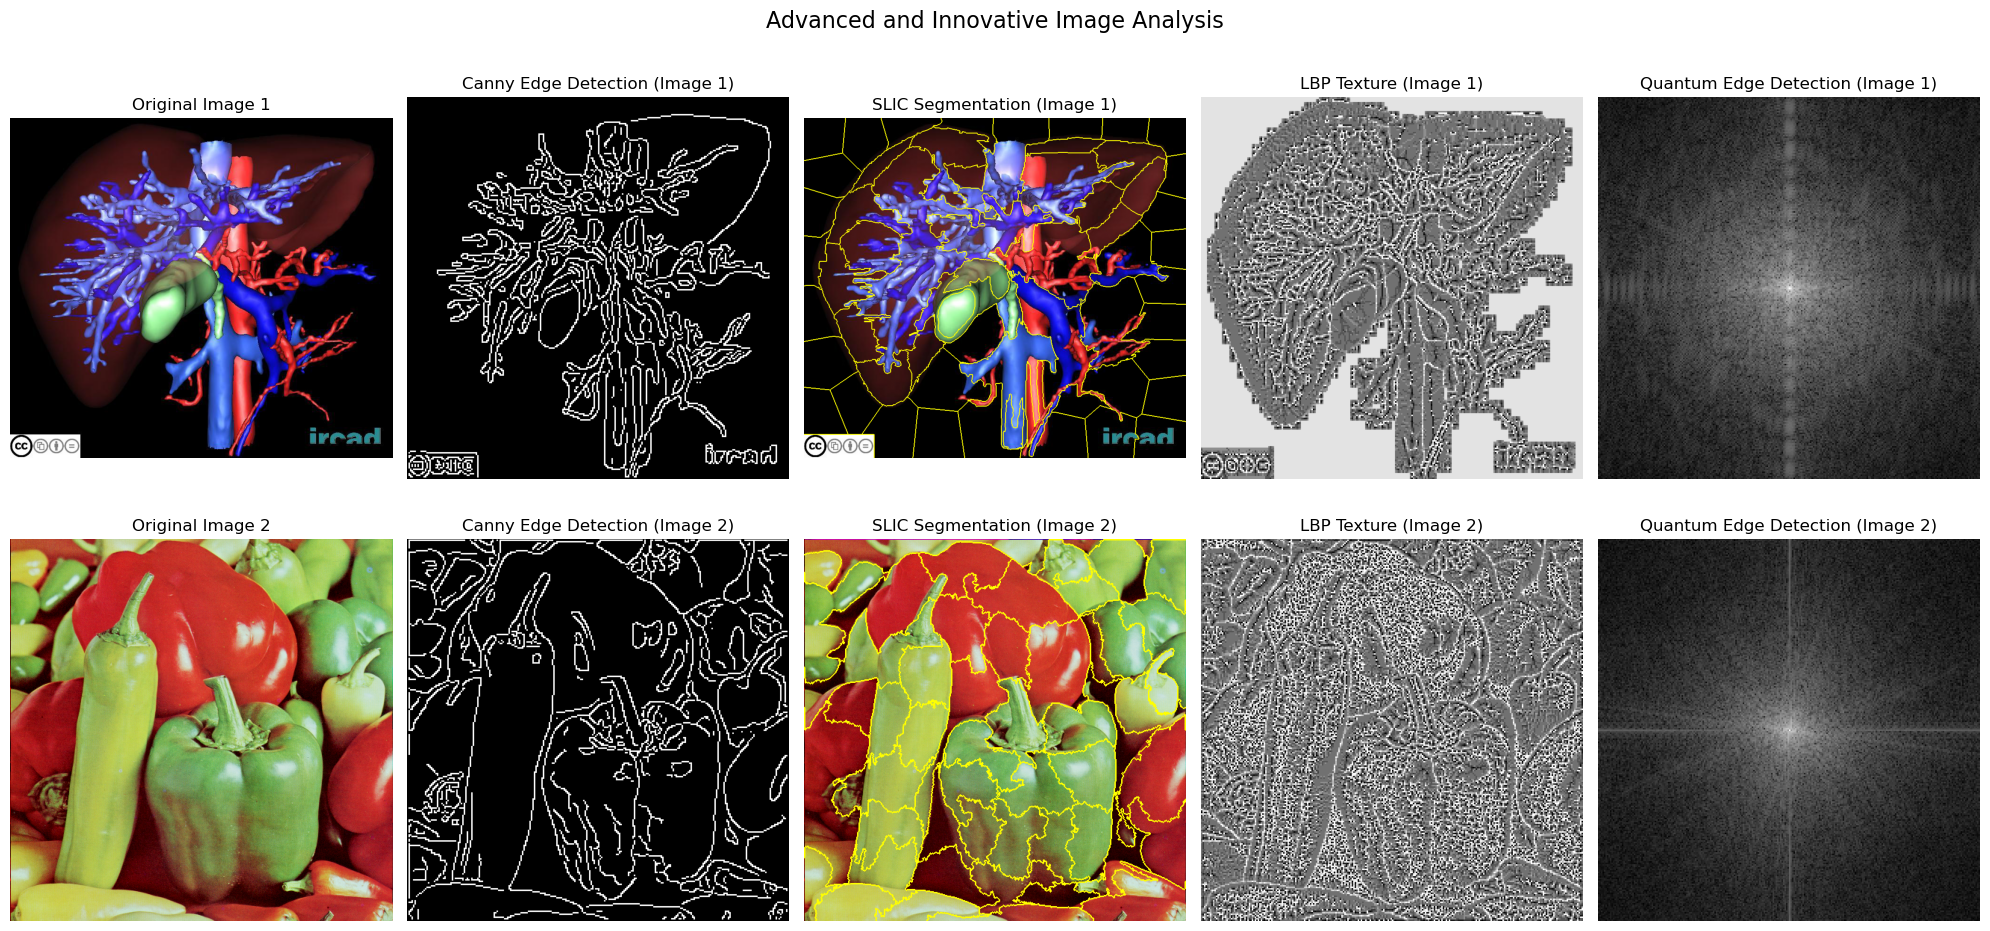

In [6]:
import matplotlib.pyplot as plt 
import numpy as np
import cv2
from skimage import io, color, feature, segmentation, measure
from skimage.transform import resize
# Removed: from skimage.future import graph
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing import image as keras_image
from sklearn.cluster import KMeans
from scipy import ndimage

# -------------------------------
# 1. Load and Preprocess the Images
# -------------------------------
# Load images using actual file paths (using raw strings for Windows paths)
image1 = io.imread(r'C:\Users\HP\Desktop\qcnn new1\3Dircadb1.11\3Dircadb1.11\Liver_11.jpg')
image2 = io.imread(r'C:\Users\HP\Desktop\qcnn new1\pepperimage.tiff')

# Print original image shapes
print("Original Image 1 shape:", image1.shape)
print("Original Image 2 shape:", image2.shape)

# Convert images to RGB if they have an alpha channel, then to grayscale if needed
if len(image1.shape) == 3:
    if image1.shape[2] == 4:
        image1 = color.rgba2rgb(image1)
    image1_gray = color.rgb2gray(image1)
else:
    image1_gray = image1

if len(image2.shape) == 3:
    if image2.shape[2] == 4:
        image2 = color.rgba2rgb(image2)
    image2_gray = color.rgb2gray(image2)
else:
    image2_gray = image2

# Resize grayscale images to 256x256 for comparison
image1_gray = resize(image1_gray, (256, 256))
image2_gray = resize(image2_gray, (256, 256))

print("Resized Image 1 (grayscale) shape:", image1_gray.shape)
print("Resized Image 2 (grayscale) shape:", image2_gray.shape)

# -------------------------------
# 2. Image Processing and Feature Extraction
# -------------------------------

# Advanced Edge Detection (Canny)
canny_edges1 = feature.canny(image1_gray, sigma=1)
canny_edges2 = feature.canny(image2_gray, sigma=1)
print("Canny Edges Image 1 shape:", canny_edges1.shape, "Edge pixels count:", np.sum(canny_edges1))
print("Canny Edges Image 2 shape:", canny_edges2.shape, "Edge pixels count:", np.sum(canny_edges2))

# Image Segmentation using SLIC (Superpixels)
segments1 = segmentation.slic(image1, n_segments=100, compactness=10)
segments2 = segmentation.slic(image2, n_segments=100, compactness=10)
print("SLIC Segmentation Image 1 - unique segments:", len(np.unique(segments1)))
print("SLIC Segmentation Image 2 - unique segments:", len(np.unique(segments2)))

# Region-based Analysis (Labeling)
label_image1 = measure.label(segments1)
label_image2 = measure.label(segments2)
print("Labeled Image 1 - number of regions:", np.max(label_image1))
print("Labeled Image 2 - number of regions:", np.max(label_image2))

# Texture Analysis using Local Binary Patterns (LBP)
lbp1 = feature.local_binary_pattern(image1_gray, P=8, R=1, method="uniform")
lbp2 = feature.local_binary_pattern(image2_gray, P=8, R=1, method="uniform")
print("LBP Image 1 - shape:", lbp1.shape, "Unique values:", np.unique(lbp1))
print("LBP Image 2 - shape:", lbp2.shape, "Unique values:", np.unique(lbp2))

# Deep Learning Feature Extraction using VGG16
def extract_vgg_features(img):
    model = VGG16(weights='imagenet', include_top=False)
    # Ensure image is 3-channel for VGG16 (convert grayscale to RGB if needed)
    if len(img.shape) == 2:
        img = np.stack((img,) * 3, axis=-1)
    img_resized = cv2.resize(img, (224, 224))  # Resize for VGG input
    img_array = keras_image.img_to_array(img_resized)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    features = model.predict(img_array)
    return features.flatten()

vgg_features1 = extract_vgg_features(image1)
vgg_features2 = extract_vgg_features(image2)
print("VGG16 features Image 1 - length:", len(vgg_features1))
print("VGG16 features Image 2 - length:", len(vgg_features2))

# Quantum-Inspired Image Processing (Simulated Quantum Edge Detection)
def quantum_edge_detection(img):
    # Use Fourier Transform to simulate quantum-inspired edge detection
    f_transform = np.fft.fft2(img)
    f_transform_shifted = np.fft.fftshift(f_transform)
    # Add 1 to avoid log(0)
    magnitude_spectrum = 20 * np.log(np.abs(f_transform_shifted) + 1)
    return magnitude_spectrum

quantum_edges1 = quantum_edge_detection(image1_gray)
quantum_edges2 = quantum_edge_detection(image2_gray)
print("Quantum Edges Image 1 - shape:", quantum_edges1.shape, "min:", np.min(quantum_edges1), "max:", np.max(quantum_edges1))
print("Quantum Edges Image 2 - shape:", quantum_edges2.shape, "min:", np.min(quantum_edges2), "max:", np.max(quantum_edges2))

# -------------------------------
# 3. Plotting and Saving the Results
# -------------------------------
# Create a figure with subplots for advanced analysis
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
fig.suptitle('Advanced and Innovative Image Analysis', fontsize=16)

# Plot the original images
axes[0, 0].imshow(image1, cmap='gray')
axes[0, 0].set_title('Original Image 1')
axes[0, 0].axis('off')

axes[1, 0].imshow(image2, cmap='gray')
axes[1, 0].set_title('Original Image 2')
axes[1, 0].axis('off')

# Plot Canny edge-detected images
axes[0, 1].imshow(canny_edges1, cmap='gray')
axes[0, 1].set_title('Canny Edge Detection (Image 1)')
axes[0, 1].axis('off')

axes[1, 1].imshow(canny_edges2, cmap='gray')
axes[1, 1].set_title('Canny Edge Detection (Image 2)')
axes[1, 1].axis('off')

# Plot SLIC segmentation results (with boundaries marked)
axes[0, 2].imshow(segmentation.mark_boundaries(image1, segments1))
axes[0, 2].set_title('SLIC Segmentation (Image 1)')
axes[0, 2].axis('off')

axes[1, 2].imshow(segmentation.mark_boundaries(image2, segments2))
axes[1, 2].set_title('SLIC Segmentation (Image 2)')
axes[1, 2].axis('off')

# Plot Local Binary Patterns (LBP) texture analysis
axes[0, 3].imshow(lbp1, cmap='gray')
axes[0, 3].set_title('LBP Texture (Image 1)')
axes[0, 3].axis('off')

axes[1, 3].imshow(lbp2, cmap='gray')
axes[1, 3].set_title('LBP Texture (Image 2)')
axes[1, 3].axis('off')

# Plot Quantum-Inspired Edge Detection results
axes[0, 4].imshow(quantum_edges1, cmap='gray')
axes[0, 4].set_title('Quantum Edge Detection (Image 1)')
axes[0, 4].axis('off')

axes[1, 4].imshow(quantum_edges2, cmap='gray')
axes[1, 4].set_title('Quantum Edge Detection (Image 2)')
axes[1, 4].axis('off')


plt.tight_layout()
plt.show()
